# P2 실습: 딥러닝 프로젝트 유형

딥러닝 프로젝트는 해결하려는 문제의 성격에 따라 여러 유형으로 나눌 수 있다.
이번 실습에서는 대표적인 유형인 **이진 분류, 다중 클래스 분류, 회귀**를 살펴본다.

다루는 문제의 유형에 따라 **출력층, 손실함수, 평가지표가 어떻게 달라지는지** 비교하고,
훈련 성능과 검증 성능을 함께 관찰하여 **일반화와 과대적합**을 확인한다.
또한 교차 검증과 규제 기법을 이용하여 모델의 일반화 성능을 평가하고 개선한다.

이번 실습의 흐름은 다음과 같다.

> **이진 분류 → 다중 클래스 분류 → 회귀 → 일반화 성능 평가 및 개선**

사용하는 데이터셋은 다음과 같다.

- IMDB 영화 후기: 이진 분류
- Reuters 뉴스 기사: 다중 클래스 분류
- California Housing: 회귀

**실습 목표**

이번 실습을 마치면 다음을 할 수 있다.

- 문제 유형에 맞게 출력층을 구성한다.
- 문제 유형에 맞는 손실함수와 평가지표를 선택한다.
- 훈련셋, 검증셋, 테스트셋의 역할을 구분한다.
- 훈련 곡선을 이용하여 과대적합을 확인한다.
- 조기 종료와 드롭아웃을 이용하여 일반화 성능을 개선한다.

**설정: TensorFlow와 Keras의 GPU 사용 가능 여부 확인**

In [1]:
# TensorFlow 를 사용할 때 기타 정보 표시 제한. Tensorflow를 불러오기 전에 실행해야 함
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import tensorflow as tf
import keras
import torch

# TensorFlow
tf_gpus = tf.config.list_physical_devices("GPU")

print("=== TensorFlow ===")
print("Version:", tf.__version__)
print("GPU 사용 가능:", len(tf_gpus) > 0)
if tf_gpus:
    print("GPU:", tf_gpus[0].name)

print()

# PyTorch
print("=== PyTorch ===")
print("Version:", torch.__version__)
print("GPU 사용 가능:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("CUDA version:", torch.version.cuda)

=== TensorFlow ===
Version: 2.20.0
GPU 사용 가능: True
GPU: /physical_device:GPU:0

=== PyTorch ===
Version: 2.9.1+cu128
GPU 사용 가능: True
GPU: NVIDIA RTX A6000
CUDA version: 12.8


## 실행 환경 확인

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import keras
from keras import layers

print("Keras:", keras.__version__)

Keras: 3.12.0


## 문제 유형에 따라 무엇이 달라질까?

세 문제는 모두 완전연결 신경망으로 해결할 수 있지만 **타깃의 의미가 다르다.**

| 문제 | 타깃 | 출력층 | 대표 손실함수 | 대표 평가지표 |
|---|---|---|---|---|
| 이진 분류 | 두 클래스 중 하나 | 1개 + sigmoid | binary crossentropy | accuracy |
| 다중 클래스 분류 | 여러 클래스 중 하나 | 클래스 수 + softmax | sparse categorical crossentropy | accuracy |
| 회귀 | 연속적인 수치 | 1개, 활성화 함수 없음 | MSE | RMSE |

실제 코드에서 이 차이를 확인한다.

## 이진 분류: IMDB 영화 후기

영화 후기의 내용을 이용하여 후기가 **긍정인지 부정인지** 예측한다.

- 입력: 영화 후기
- 타깃: `0`(부정), `1`(긍정)
- 문제 유형: **이진 분류**

### IMDB 데이터 불러오기

In [3]:
from keras.datasets import imdb

(train_data, train_labels), (test_data, test_labels) = imdb.load_data(
    num_words=10000
)

print("훈련 샘플 수:", len(train_data))
print("테스트 샘플 수:", len(test_data))
print("첫 번째 타깃:", train_labels[0])
print("첫 번째 후기의 단어 수:", len(train_data[0]))

훈련 샘플 수: 25000
테스트 샘플 수: 25000
첫 번째 타깃: 1
첫 번째 후기의 단어 수: 218


각 후기는 문장 자체가 아니라 **단어를 나타내는 정수 인덱스의 목록**으로 저장되어 있다.

후기마다 길이가 다르므로 그대로 Dense 층의 입력으로 사용할 수 없다.
여기서는 가장 자주 등장하는 10,000개 단어의 **등장 여부**를 나타내는 벡터로 변환한다.

### 입력 데이터 벡터화

In [4]:
def multi_hot_encode(sequences, num_classes=10000):
    results = np.zeros((len(sequences), num_classes), dtype="float32")
    for i, sequence in enumerate(sequences):
        results[i, sequence] = 1.0
    return results

x_train = multi_hot_encode(train_data)
x_test = multi_hot_encode(test_data)

y_train = train_labels.astype("float32")
y_test = test_labels.astype("float32")

print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)

x_train shape: (25000, 10000)
y_train shape: (25000,)


### 훈련셋과 검증셋 분리

테스트셋은 **최종 평가**에만 사용한다.

훈련 중 모델을 비교하고 훈련을 언제 멈출지 판단하기 위해
훈련셋의 일부를 **검증셋**으로 분리한다.

In [5]:
imdb_x_val = x_train[:10000]
imdb_partial_x_train = x_train[10000:]

imdb_y_val = y_train[:10000]
imdb_partial_y_train = y_train[10000:]

print("실제 훈련셋:", imdb_partial_x_train.shape)
print("검증셋:", imdb_x_val.shape)
print("테스트셋:", x_test.shape)

실제 훈련셋: (15000, 10000)
검증셋: (10000, 10000)
테스트셋: (25000, 10000)


### 이진 분류 모델 구성

In [6]:
binary_model = keras.Sequential([
    layers.Dense(16, activation="relu"),
    layers.Dense(16, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

binary_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

binary_model.summary()

I0000 00:00:1789646259.985106  242299 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 46007 MB memory:  -> device: 0, name: NVIDIA RTX A6000, pci bus id: 0000:01:00.0, compute capability: 8.6


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

출력층에 주목한다.

```text
Dense(1, activation="sigmoid")
```

하나의 값이 `0~1` 사이의 값으로 출력되며,
이를 긍정일 가능성을 나타내는 값으로 해석할 수 있다.

### 모델 훈련

In [7]:
binary_history = binary_model.fit(
    imdb_partial_x_train,
    imdb_partial_y_train,
    epochs=20,
    batch_size=512,
    validation_data=(imdb_x_val, imdb_y_val),
    verbose=1
)

Epoch 1/20
18/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6293 - loss: 0.6610

I0000 00:00:1789646263.510209  242414 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 54ms/step - accuracy: 0.7659 - loss: 0.5575 - val_accuracy: 0.8483 - val_loss: 0.4122
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8972 - loss: 0.3112 - val_accuracy: 0.8859 - val_loss: 0.3006
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9297 - loss: 0.2114 - val_accuracy: 0.8906 - val_loss: 0.2769
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9513 - loss: 0.1566 - val_accuracy: 0.8866 - val_loss: 0.2794
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9654 - loss: 0.1203 - val_accuracy: 0.8844 - val_loss: 0.2950
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9747 - loss: 0.0940 - val_accuracy: 0.8809 - val_loss: 0.3099
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9841 - loss: 0.0722 - val_accuracy: 0.8823 - val_loss: 0.3333
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9893 - loss: 0.0560 - val_accuracy: 0.8782 - val_loss: 0.3610
Ep

### 훈련 과정 확인

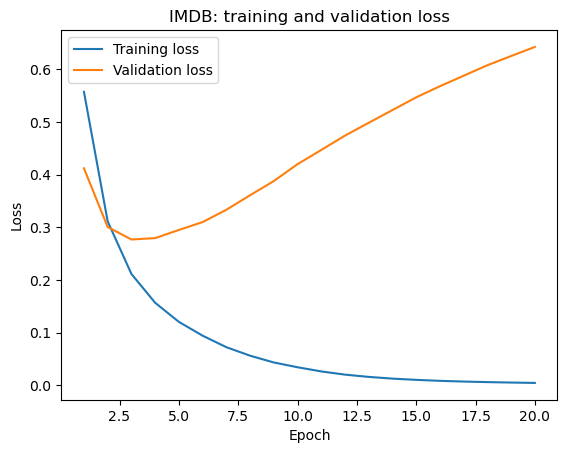

In [8]:
epochs = range(1, len(binary_history.history["loss"]) + 1)

plt.figure()
plt.plot(epochs, binary_history.history["loss"], label="Training loss")
plt.plot(epochs, binary_history.history["val_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("IMDB: training and validation loss")
plt.legend()
plt.show()

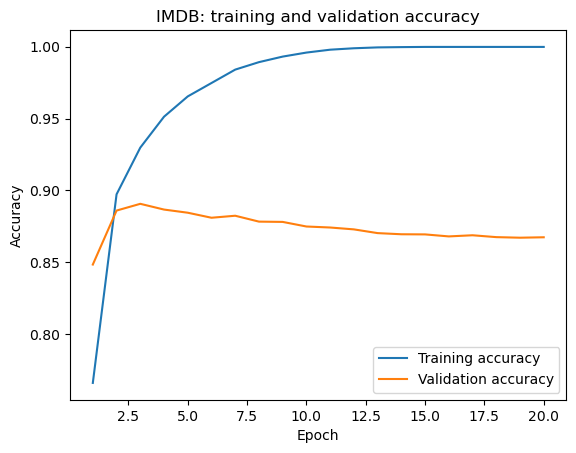

In [9]:
plt.figure()
plt.plot(epochs, binary_history.history["accuracy"], label="Training accuracy")
plt.plot(epochs, binary_history.history["val_accuracy"], label="Validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("IMDB: training and validation accuracy")
plt.legend()
plt.show()

그래프를 보고 다음을 확인한다.

- 훈련 손실은 계속 감소하는가?
- 검증 손실은 어느 시점부터 다시 증가하는가?
- 훈련 정확도와 검증 정확도의 차이는 어떻게 변하는가?

> 훈련 성능은 계속 좋아지지만 검증 성능이 더 이상 좋아지지 않거나 나빠지기 시작하면 **과대적합**이 발생하고 있다고 볼 수 있다.

### 테스트 데이터에서 최종 평가

In [10]:
binary_test_loss, binary_test_acc = binary_model.evaluate(
    x_test, y_test, verbose=0
)

print("test loss:", binary_test_loss)
print("test accuracy:", binary_test_acc)

test loss: 0.6989365816116333
test accuracy: 0.8549200296401978


### 예측값 확인

In [11]:
binary_predictions = binary_model.predict(x_test[:10], verbose=0).reshape(-1)

for i, p in enumerate(binary_predictions):
    predicted_label = int(p >= 0.5)
    print(
        f"{i:2d}: probability={p:.3f}, "
        f"prediction={predicted_label}, target={int(y_test[i])}"
    )

 0: probability=0.010, prediction=0, target=0
 1: probability=1.000, prediction=1, target=1
 2: probability=0.982, prediction=1, target=1
 3: probability=0.973, prediction=1, target=0
 4: probability=0.997, prediction=1, target=1
 5: probability=1.000, prediction=1, target=1
 6: probability=0.993, prediction=1, target=1
 7: probability=0.000, prediction=0, target=0
 8: probability=0.988, prediction=1, target=0
 9: probability=1.000, prediction=1, target=1


## 다중 클래스 분류: Reuters 뉴스 기사

이번에는 뉴스 기사를 **46개의 주제 중 하나**로 분류한다.

- 입력: Reuters 뉴스 기사
- 타깃: `0~45`의 주제 번호
- 문제 유형: **다중 클래스 분류**

P1의 MNIST와 마찬가지로 여러 클래스 중 하나를 선택하지만,
이번에는 이미지가 아니라 벡터화된 텍스트를 입력으로 사용한다.

### Reuters 데이터 불러오기

In [12]:
from keras.datasets import reuters

(reuters_train_data, reuters_train_labels), (
    reuters_test_data,
    reuters_test_labels
) = reuters.load_data(num_words=10000)

print("훈련 샘플 수:", len(reuters_train_data))
print("테스트 샘플 수:", len(reuters_test_data))
print("클래스 수:", np.max(reuters_train_labels) + 1)

훈련 샘플 수: 8982
테스트 샘플 수: 2246
클래스 수: 46


### 입력 데이터 벡터화

In [13]:
rx_train = multi_hot_encode(reuters_train_data)
rx_test = multi_hot_encode(reuters_test_data)

# 타깃은 0~45의 정수 범주를 그대로 사용
ry_train = np.asarray(reuters_train_labels, dtype="int64")
ry_test = np.asarray(reuters_test_labels, dtype="int64")

print("입력 shape:", rx_train.shape)
print("타깃 shape:", ry_train.shape)
print("타깃 예:", ry_train[:10])

입력 shape: (8982, 10000)
타깃 shape: (8982,)
타깃 예: [ 3  4  3  4  4  4  4  3  3 16]


### 훈련셋과 검증셋 분리

In [14]:
rx_val = rx_train[:1000]
partial_rx_train = rx_train[1000:]

ry_val = ry_train[:1000]
partial_ry_train = ry_train[1000:]

print("실제 훈련셋:", partial_rx_train.shape)
print("검증셋:", rx_val.shape)

실제 훈련셋: (7982, 10000)
검증셋: (1000, 10000)


### 다중 클래스 분류 모델 구성

In [15]:
top_3_accuracy = keras.metrics.SparseTopKCategoricalAccuracy(
    k=3,
    name="top_3_accuracy"
)

multiclass_model = keras.Sequential([
    layers.Dense(64, activation="relu"),
    layers.Dense(64, activation="relu"),
    layers.Dense(46, activation="softmax")
])

multiclass_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy", top_3_accuracy]
)

multiclass_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

출력층은 클래스 수와 같은 46개의 유닛을 사용한다.

```text
Dense(46, activation="softmax")
```

각 샘플에 대해 46개 클래스의 확률이 출력되며,
이 값들의 합은 1이다.

타깃을 정수 범주 그대로 사용했으므로
`sparse_categorical_crossentropy`를 사용한다.

### 모델 훈련

In [16]:
multiclass_history = multiclass_model.fit(
    partial_rx_train,
    partial_ry_train,
    epochs=20,
    batch_size=512,
    validation_data=(rx_val, ry_val),
    verbose=1
)

Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 7s 272ms/step - accuracy: 0.4235 - loss: 3.2815 - top_3_accuracy: 0.5666 - val_accuracy: 0.5510 - val_loss: 2.5100 - val_top_3_accuracy: 0.7010
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6337 - loss: 1.9678 - top_3_accuracy: 0.7509 - val_accuracy: 0.6620 - val_loss: 1.6166 - val_top_3_accuracy: 0.7620
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7225 - loss: 1.3132 - top_3_accuracy: 0.8180 - val_accuracy: 0.7180 - val_loss: 1.2684 - val_top_3_accuracy: 0.8290
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7805 - loss: 1.0080 - top_3_accuracy: 0.8691 - val_accuracy: 0.7590 - val_loss: 1.1262 - val_top_3_accuracy: 0.8510
Epoch 5/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8344 - loss: 0.7907 - top_3_accuracy: 0.9052 - val_accuracy: 0.7920 - val_loss: 1.0203 - val_top_3_accuracy: 0.8810
Epoch 6/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8707 - loss: 0.6203 - top_3_accura

### 훈련 과정 확인

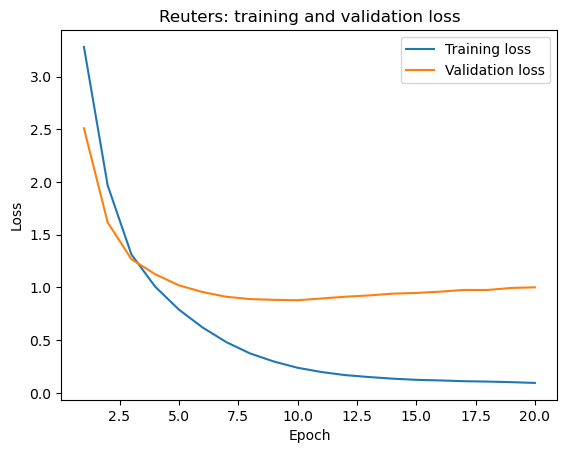

In [17]:
mc_epochs = range(1, len(multiclass_history.history["loss"]) + 1)

plt.figure()
plt.plot(mc_epochs, multiclass_history.history["loss"], label="Training loss")
plt.plot(mc_epochs, multiclass_history.history["val_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Reuters: training and validation loss")
plt.legend()
plt.show()

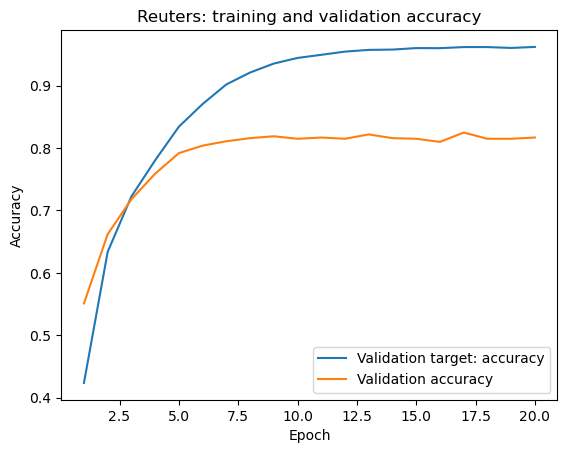

In [18]:
plt.figure()
plt.plot(mc_epochs, multiclass_history.history["accuracy"], label="Validation target: accuracy")
plt.plot(mc_epochs, multiclass_history.history["val_accuracy"], label="Validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Reuters: training and validation accuracy")
plt.legend()
plt.show()

`accuracy`는 정답 클래스가 **가장 높은 확률을 가진 클래스인지**만 확인한다.

Reuters처럼 클래스 수가 많은 경우에는 정답이 상위 몇 개의 후보 안에 포함되었는지도 확인할 수 있다.
여기서는 `top_3_accuracy`를 함께 기록했다.

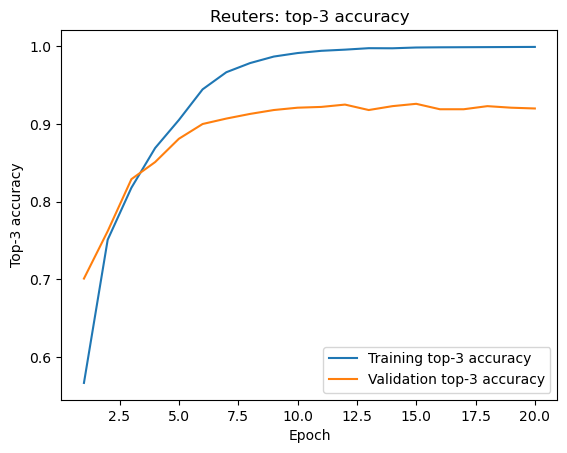

In [19]:
plt.figure()
plt.plot(
    mc_epochs,
    multiclass_history.history["top_3_accuracy"],
    label="Training top-3 accuracy"
)
plt.plot(
    mc_epochs,
    multiclass_history.history["val_top_3_accuracy"],
    label="Validation top-3 accuracy"
)
plt.xlabel("Epoch")
plt.ylabel("Top-3 accuracy")
plt.title("Reuters: top-3 accuracy")
plt.legend()
plt.show()

### 예측 확률 확인

In [20]:
mc_predictions = multiclass_model.predict(rx_test[:3], verbose=0)

print("한 샘플의 출력 shape:", mc_predictions[0].shape)
print("확률 합:", mc_predictions[0].sum())
print("예측 클래스:", mc_predictions[0].argmax())
print("실제 클래스:", ry_test[0])

한 샘플의 출력 shape: (46,)
확률 합: 1.0
예측 클래스: 3
실제 클래스: 3


### 테스트 데이터에서 최종 평가

In [21]:
mc_results = multiclass_model.evaluate(rx_test, ry_test, verbose=0)

print("test loss:", mc_results[0])
print("test accuracy:", mc_results[1])
print("test top-3 accuracy:", mc_results[2])

test loss: 1.0905535221099854
test accuracy: 0.7947462201118469
test top-3 accuracy: 0.9113980531692505


## 회귀: California Housing

분류에서는 범주를 예측했지만 회귀에서는 **연속적인 수치**를 예측한다.

California Housing 데이터셋에서는 지역의 인구·소득·주택 관련 특성을 이용하여
**중앙 주택가격**을 예측한다.

이번 실습에서는 기존 참고 자료의 Boston Housing 예제를
California Housing 데이터셋으로 바꾸어 사용한다.

### California Housing 데이터 불러오기

In [22]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split

housing = fetch_california_housing()

X = housing.data.astype("float32")
y = housing.target.astype("float32")

print("입력 shape:", X.shape)
print("타깃 shape:", y.shape)
print("특성 이름:", housing.feature_names)
print("타깃 예:", y[:5])

입력 shape: (20640, 8)
타깃 shape: (20640,)
특성 이름: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
타깃 예: [4.526 3.585 3.521 3.413 3.422]


`target`은 지역별 중앙 주택가격을 나타내며 **10만 달러 단위**로 저장되어 있다.

예를 들어 타깃이 `2.5`라면 약 25만 달러를 의미한다.

### 훈련셋과 테스트셋 분리

테스트셋은 **최종 평가**에만 사용한다.

나머지 훈련 데이터에서는 하나의 검증셋을 고정하지 않고
**3겹 교차 검증**(3-fold cross-validation)을 사용하여 모델의 일반화 성능을 평가한다.

In [23]:
from sklearn.model_selection import train_test_split

housing_X_train, housing_X_test, housing_y_train, housing_y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("교차 검증에 사용할 훈련 데이터:", housing_X_train.shape)
print("최종 테스트 데이터:", housing_X_test.shape)

교차 검증에 사용할 훈련 데이터: (16512, 8)
최종 테스트 데이터: (4128, 8)


### 3겹 교차 검증

훈련 데이터를 세 부분으로 나눈 뒤,

> **2개 fold로 훈련 → 남은 1개 fold로 검증**

하는 과정을 세 번 반복한다.

각 fold가 한 번씩 검증 데이터가 되며,
세 번의 검증 **RMSE**를 평균하여 모델의 일반화 성능을 평가한다.

RMSE는 오차를 제곱하여 평균한 뒤 다시 제곱근을 취한 값으로,
타깃과 같은 단위를 사용한다.

### 회귀 모델 생성 함수

교차 검증에서는 fold마다 **새로운 모델을 처음부터 생성하여 훈련**해야 한다.

손실함수는 평균제곱오차(MSE)를 사용하고,
평가지표는 평균제곱근오차(RMSE)를 사용한다.

In [24]:
def build_regression_model():
    model = keras.Sequential([
        layers.Dense(64, activation="relu"),
        layers.Dense(64, activation="relu"),
        layers.Dense(1)
    ])

    model.compile(
        optimizer="adam",
        loss="mse",
        metrics=[
            keras.metrics.RootMeanSquaredError(name="rmse")
        ]
    )

    return model

회귀 모델의 출력층은

```text
Dense(1)
```

처럼 **활성화 함수를 사용하지 않는다.**

출력값을 `0~1` 또는 클래스 확률로 제한할 필요가 없기 때문이다.

### fold마다 입력 특성 표준화

표준화에 사용하는 평균과 표준편차도 검증 데이터에서 미리 얻어서는 안 된다.

따라서 각 fold에서

> **훈련 fold로 scaler 학습 → 훈련 fold와 검증 fold에 같은 변환 적용**

순서로 표준화한다.

In [25]:
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler

kfold = KFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

fold_rmse = []
fold_best_epochs = []
fold_histories = []

for fold, (train_idx, val_idx) in enumerate(kfold.split(housing_X_train), start=1):
    print(f"\nfold {fold}")

    fold_X_train = housing_X_train[train_idx]
    fold_y_train = housing_y_train[train_idx]

    fold_X_val = housing_X_train[val_idx]
    fold_y_val = housing_y_train[val_idx]

    # 이 fold의 훈련 데이터만 이용하여 표준화 기준을 학습
    scaler = StandardScaler()
    fold_X_train_scaled = scaler.fit_transform(fold_X_train).astype("float32")
    fold_X_val_scaled = scaler.transform(fold_X_val).astype("float32")

    model = build_regression_model()

    early_stopping = keras.callbacks.EarlyStopping(
        monitor="val_rmse",
        mode="min",
        patience=10,
        restore_best_weights=True
    )

    history = model.fit(
        fold_X_train_scaled,
        fold_y_train,
        epochs=200,
        batch_size=64,
        validation_data=(fold_X_val_scaled, fold_y_val),
        callbacks=[early_stopping],
        verbose=0
    )

    # restore_best_weights=True이므로 현재 모델은 가장 좋은 검증 성능의 가중치를 사용한다.
    val_loss, val_rmse = model.evaluate(
        fold_X_val_scaled,
        fold_y_val,
        verbose=0
    )

    best_epoch = int(np.argmin(history.history["val_rmse"]) + 1)

    fold_rmse.append(val_rmse)
    fold_best_epochs.append(best_epoch)
    fold_histories.append(history.history)

    print(f"best epoch: {best_epoch}")
    print(f"validation RMSE: {val_rmse:.4f}")


fold 1
best epoch: 93
validation RMSE: 0.5233

fold 2
best epoch: 85
validation RMSE: 0.5170

fold 3
best epoch: 47
validation RMSE: 0.5351


### 교차 검증 결과

In [26]:
for fold, score in enumerate(fold_rmse, start=1):
    print(f"fold {fold} RMSE: {score:.4f}")

mean_cv_rmse = np.mean(fold_rmse)
std_cv_rmse = np.std(fold_rmse)

print()
print(f"평균 validation RMSE: {mean_cv_rmse:.4f}")
print(f"validation RMSE 표준편차: {std_cv_rmse:.4f}")

fold 1 RMSE: 0.5233
fold 2 RMSE: 0.5170
fold 3 RMSE: 0.5351

평균 validation RMSE: 0.5251
validation RMSE 표준편차: 0.0075


California Housing의 타깃은 **10만 달러 단위**이므로,
예를 들어 RMSE가 `0.50`이라면 예측 오차의 대표적인 크기는 약 **5만 달러** 수준으로 해석할 수 있다.

교차 검증에서는 하나의 검증셋 결과가 아니라
서로 다른 세 검증 fold에서 얻은 RMSE를 함께 확인한다.

### fold별 검증 RMSE 변화

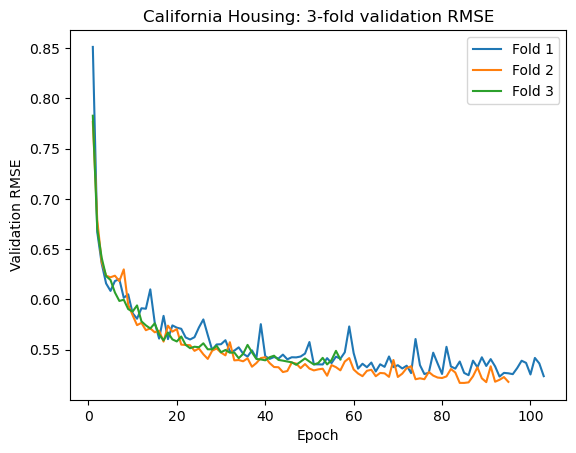

In [27]:
plt.figure()

for fold, history in enumerate(fold_histories, start=1):
    epochs = range(1, len(history["val_rmse"]) + 1)
    plt.plot(
        epochs,
        history["val_rmse"],
        label=f"Fold {fold}"
    )

plt.xlabel("Epoch")
plt.ylabel("Validation RMSE")
plt.title("California Housing: 3-fold validation RMSE")
plt.legend()
plt.show()

### 최종 훈련 에포크 결정

각 fold에서 검증 RMSE가 가장 낮았던 에포크를 확인하고,
그 평균을 최종 모델의 훈련 에포크 수로 사용한다.

테스트셋은 이 결정 과정에 사용하지 않는다.

In [28]:
final_epochs = int(round(np.mean(fold_best_epochs)))

print("fold별 best epoch:", fold_best_epochs)
print("최종 훈련 epoch:", final_epochs)

fold별 best epoch: [93, 85, 47]
최종 훈련 epoch: 75


### 전체 훈련 데이터로 최종 모델 훈련

교차 검증이 끝나면 테스트 데이터를 제외한 전체 훈련 데이터를 이용하여
새로운 모델을 처음부터 다시 훈련한다.

표준화 기준도 전체 훈련 데이터에서 새로 계산한 뒤
같은 기준을 테스트 데이터에 적용한다.

In [29]:
final_scaler = StandardScaler()

housing_X_train_scaled = final_scaler.fit_transform(
    housing_X_train
).astype("float32")

housing_X_test_scaled = final_scaler.transform(
    housing_X_test
).astype("float32")

regression_model = build_regression_model()

regression_history = regression_model.fit(
    housing_X_train_scaled,
    housing_y_train,
    epochs=final_epochs,
    batch_size=64,
    verbose=1
)

Epoch 1/75
258/258 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 1.2024 - rmse: 1.0965
Epoch 2/75
258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4340 - rmse: 0.6588
Epoch 3/75
258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3815 - rmse: 0.6176
Epoch 4/75
258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3639 - rmse: 0.6033
Epoch 5/75
258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3472 - rmse: 0.5892
Epoch 6/75
258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3428 - rmse: 0.5855
Epoch 7/75
258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3303 - rmse: 0.5747
Epoch 8/75
258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3216 - rmse: 0.5671
Epoch 9/75
258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3157 - rmse: 0.5619
Epoch 10/75
258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3110 - rmse: 0.5576
Epoch 11/75
258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3228 - rmse: 0.5681
Epoch 12/75
258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3101 - rmse: 0.5568
Epoch 13/75
2

### 테스트 데이터에서 최종 평가

In [30]:
reg_test_mse, reg_test_rmse = regression_model.evaluate(
    housing_X_test_scaled,
    housing_y_test,
    verbose=0
)

print("test MSE:", reg_test_mse)
print("test RMSE:", reg_test_rmse)
print("달러 기준 RMSE(대략):", reg_test_rmse * 100000)

test MSE: 0.2769198715686798
test RMSE: 0.5262317657470703
달러 기준 RMSE(대략): 52623.17657470703


### 실제값과 예측값 비교

In [31]:
reg_predictions = regression_model.predict(
    housing_X_test_scaled[:10],
    verbose=0
).reshape(-1)

for actual, predicted in zip(housing_y_test[:10], reg_predictions):
    print(
        f"actual={actual:.3f}, "
        f"predicted={predicted:.3f}, "
        f"error={predicted - actual:+.3f}"
    )

actual=0.477, predicted=0.442, error=-0.035
actual=0.458, predicted=0.693, error=+0.235
actual=5.000, predicted=4.476, error=-0.524
actual=2.186, predicted=2.476, error=+0.290
actual=2.780, predicted=2.311, error=-0.469
actual=1.587, predicted=1.614, error=+0.027
actual=1.982, predicted=2.587, error=+0.605
actual=1.575, predicted=1.592, error=+0.017
actual=3.400, predicted=2.457, error=-0.943
actual=4.466, predicted=4.900, error=+0.434


## Keras에서 훈련 과정 관리하기: 콜백

Keras의 `fit()`은 모델 훈련을 내부에서 수행하지만,
훈련 과정에서 계산되는 손실값과 평가지표를 관찰하고
필요한 동작을 실행하도록 **콜백**(callback)을 지정할 수 있다.

P2에서는 일반화 성능을 확인하고 과대적합에 대응하기 위해 다음 콜백을 사용한다.

- `EarlyStopping`: 검증 성능이 더 이상 개선되지 않으면 훈련을 종료
- `ModelCheckpoint`: 훈련 중 가장 좋은 성능의 모델을 저장
- `ReduceLROnPlateau`: 검증 성능이 정체되면 학습률을 줄임

콜백은 `fit()`의 `callbacks` 인자로 전달한다.

### EarlyStopping과 ModelCheckpoint

먼저 IMDB 이진 분류 모델에 두 콜백을 함께 적용한다.

`EarlyStopping`은 검증 손실이 더 이상 좋아지지 않으면 훈련을 멈추고,
`ModelCheckpoint`는 검증 손실이 가장 낮았던 모델을 파일로 저장한다.

In [32]:
checkpoint_path = "p2_imdb_best_model.keras"

callback_model = keras.Sequential([
    layers.Dense(16, activation="relu"),
    layers.Dense(16, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

callback_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

callbacks_list = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=2,
        restore_best_weights=True,
    ),
    keras.callbacks.ModelCheckpoint(
        filepath=checkpoint_path,
        monitor="val_loss",
        save_best_only=True,
    ),
]

callback_history = callback_model.fit(
    imdb_partial_x_train,
    imdb_partial_y_train,
    epochs=20,
    batch_size=512,
    validation_data=(imdb_x_val, imdb_y_val),
    callbacks=callbacks_list,
    verbose=1,
)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - accuracy: 0.7561 - loss: 0.5791 - val_accuracy: 0.8507 - val_loss: 0.4349
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8967 - loss: 0.3280 - val_accuracy: 0.8853 - val_loss: 0.3068
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9281 - loss: 0.2185 - val_accuracy: 0.8911 - val_loss: 0.2772
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9485 - loss: 0.1615 - val_accuracy: 0.8889 - val_loss: 0.2779
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9635 - loss: 0.1245 - val_accuracy: 0.8870 - val_loss: 0.2916


`epochs=20`은 최대 훈련 횟수다.
검증 손실이 더 이상 개선되지 않으면 실제 훈련은 그보다 일찍 종료될 수 있다.

`restore_best_weights=True`를 사용하면 훈련이 종료된 뒤
검증 손실이 가장 좋았던 시점의 가중치로 되돌아간다.

`ModelCheckpoint`는 같은 시점의 전체 모델을 파일로 저장할 수 있다.

In [33]:
best_model = keras.models.load_model(checkpoint_path)

best_test_loss, best_test_acc = best_model.evaluate(
    x_test,
    y_test,
    verbose=0,
)

print("best model test loss:", best_test_loss)
print("best model test accuracy:", best_test_acc)

best model test loss: 0.2954217493534088
best model test accuracy: 0.8826000094413757


### 학습률 조정

검증 손실이 일정 기간 개선되지 않을 때
학습률을 줄이는 방법도 사용할 수 있다.

`ReduceLROnPlateau`는 모델이 현재 학습률에서 더 이상 충분히 개선되지 않을 때
학습률을 자동으로 낮춘다.

In [34]:
lr_model = keras.Sequential([
    layers.Dense(16, activation="relu"),
    layers.Dense(16, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

lr_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

lr_callbacks = [
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=1,
        min_lr=1e-5,
        verbose=1,
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True,
    ),
]

lr_history = lr_model.fit(
    imdb_partial_x_train,
    imdb_partial_y_train,
    epochs=20,
    batch_size=512,
    validation_data=(imdb_x_val, imdb_y_val),
    callbacks=lr_callbacks,
    verbose=1,
)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step - accuracy: 0.7495 - loss: 0.5546 - val_accuracy: 0.8627 - val_loss: 0.4009 - learning_rate: 0.0010
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9007 - loss: 0.3011 - val_accuracy: 0.8876 - val_loss: 0.2971 - learning_rate: 0.0010
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9350 - loss: 0.2014 - val_accuracy: 0.8890 - val_loss: 0.2795 - learning_rate: 0.0010
Epoch 4/20
27/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9583 - loss: 0.1432
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9551 - loss: 0.1448 - val_accuracy: 0.8831 - val_loss: 0.2864 - learning_rate: 0.0010
Epoch 5/20
15/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9731 - loss: 0.1043 
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9727 - loss: 0.1079 - val_accuracy: 

## 일반화: IMDB 모델 다시 살펴보기

앞의 IMDB 모델에서 훈련 성능과 검증 성능의 차이가 커지는 현상을 관찰했다.

이번에는 같은 문제에 다음 세 방법을 적용한다.

- **L2 가중치 규제**: 큰 가중치에 패널티를 주어 모델이 지나치게 복잡한 표현에 의존하지 않도록 한다.
- **드롭아웃**: 훈련 중 일부 유닛의 출력을 무작위로 0으로 만들어 과도한 적응을 방해한다.
- **조기 종료**: 검증 성능이 더 이상 좋아지지 않으면 훈련을 멈춘다.

먼저 L2 가중치 규제를 단독으로 적용한 뒤,
드롭아웃과 조기 종료를 적용한 모델과 비교한다.

### L2 가중치 규제

**L2 가중치 규제**(L2 weight regularization)는
큰 가중치에 비용을 추가하여 가중치가 지나치게 커지는 것을 억제한다.

기본 손실함수가 $L$이고 가중치가 $w$라면,
L2 규제를 적용한 손실은 다음과 같이 생각할 수 있다.

$$
L_{regularized}
=
L
+
\lambda \sum_i w_i^2
$$

여기서 $\lambda$는 규제의 강도를 조절하는 값이다.

Keras에서는 `kernel_regularizer`를 이용하여 층의 가중치에
L2 규제를 적용할 수 있다.

In [35]:
from keras import regularizers

l2_model = keras.Sequential([
    layers.Dense(
        16,
        activation="relu",
        kernel_regularizer=regularizers.l2(0.002)
    ),
    layers.Dense(
        16,
        activation="relu",
        kernel_regularizer=regularizers.l2(0.002)
    ),
    layers.Dense(1, activation="sigmoid")
])

l2_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

l2_history = l2_model.fit(
    imdb_partial_x_train,
    imdb_partial_y_train,
    epochs=20,
    batch_size=512,
    validation_data=(imdb_x_val, imdb_y_val),
    verbose=1
)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - accuracy: 0.7465 - loss: 0.6632 - val_accuracy: 0.8514 - val_loss: 0.5165
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8882 - loss: 0.4209 - val_accuracy: 0.8801 - val_loss: 0.3964
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9159 - loss: 0.3274 - val_accuracy: 0.8849 - val_loss: 0.3677
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9307 - loss: 0.2891 - val_accuracy: 0.8771 - val_loss: 0.3799
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9385 - loss: 0.2657 - val_accuracy: 0.8844 - val_loss: 0.3656
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9493 - loss: 0.2480 - val_accuracy: 0.8819 - val_loss: 0.3667
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9528 - loss: 0.2353 - val_accuracy: 0.8803 - val_loss: 0.3738
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9577 - loss: 0.2237 - val_accuracy: 0.8823 - val_los

L2 규제를 적용해도 훈련 데이터에 대한 손실을 줄이는 것이 목표이지만,
동시에 큰 가중치에 대한 패널티가 추가된다.

따라서 기본 모델보다 훈련 손실이 더 높을 수 있으며,
중요한 것은 **검증 손실이 언제부터 증가하는지와 증가 정도가 어떻게 달라지는지** 확인하는 것이다.

### 기본 모델과 L2 규제 모델의 검증 손실 비교

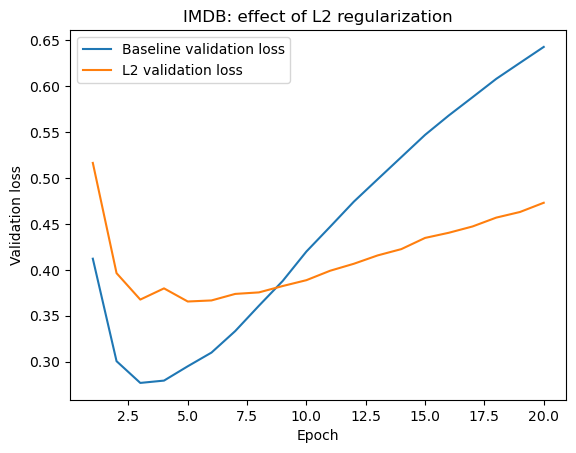

In [36]:
plt.figure()

plt.plot(
    range(1, len(binary_history.history["val_loss"]) + 1),
    binary_history.history["val_loss"],
    label="Baseline validation loss"
)

plt.plot(
    range(1, len(l2_history.history["val_loss"]) + 1),
    l2_history.history["val_loss"],
    label="L2 validation loss"
)

plt.xlabel("Epoch")
plt.ylabel("Validation loss")
plt.title("IMDB: effect of L2 regularization")
plt.legend()
plt.show()

### 드롭아웃을 적용한 모델

In [37]:
regularized_model = keras.Sequential([
    layers.Dense(16, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(16, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(1, activation="sigmoid")
])

regularized_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

early_stopping_imdb = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

regularized_history = regularized_model.fit(
    imdb_partial_x_train,
    imdb_partial_y_train,
    epochs=20,
    batch_size=512,
    validation_data=(imdb_x_val, imdb_y_val),
    callbacks=[early_stopping_imdb],
    verbose=1
)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 65ms/step - accuracy: 0.5942 - loss: 0.6612 - val_accuracy: 0.8157 - val_loss: 0.5778
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7332 - loss: 0.5476 - val_accuracy: 0.8588 - val_loss: 0.4501
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8051 - loss: 0.4494 - val_accuracy: 0.8767 - val_loss: 0.3601
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8485 - loss: 0.3810 - val_accuracy: 0.8846 - val_loss: 0.3089
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8777 - loss: 0.3288 - val_accuracy: 0.8890 - val_loss: 0.2872
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9024 - loss: 0.2889 - val_accuracy: 0.8883 - val_loss: 0.2750
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9171 - loss: 0.2488 - val_accuracy: 0.8895 - val_loss: 0.2737
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9313 - loss: 0.2160 - val_accuracy: 0.8905 - val_los

### 기본 모델, L2 규제 모델, 드롭아웃 모델 비교

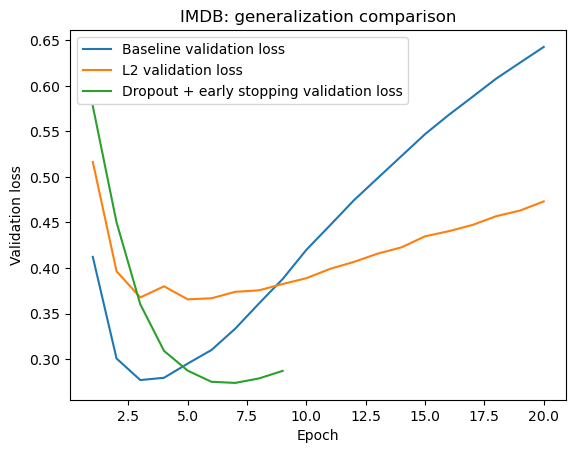

In [38]:
plt.figure()

plt.plot(
    range(1, len(binary_history.history["val_loss"]) + 1),
    binary_history.history["val_loss"],
    label="Baseline validation loss"
)

plt.plot(
    range(1, len(l2_history.history["val_loss"]) + 1),
    l2_history.history["val_loss"],
    label="L2 validation loss"
)

plt.plot(
    range(1, len(regularized_history.history["val_loss"]) + 1),
    regularized_history.history["val_loss"],
    label="Dropout + early stopping validation loss"
)

plt.xlabel("Epoch")
plt.ylabel("Validation loss")
plt.title("IMDB: generalization comparison")
plt.legend()
plt.show()

### 규제 모델의 테스트 성능

In [39]:
l2_test_loss, l2_test_acc = l2_model.evaluate(
    x_test, y_test, verbose=0
)

reg_binary_test_loss, reg_binary_test_acc = regularized_model.evaluate(
    x_test, y_test, verbose=0
)

print("baseline test accuracy:", binary_test_acc)
print("L2 test accuracy:", l2_test_acc)
print("dropout + early stopping test accuracy:", reg_binary_test_acc)

baseline test accuracy: 0.8549200296401978
L2 test accuracy: 0.8593999743461609
dropout + early stopping test accuracy: 0.8835999965667725


## PyTorch로 일반화 확인하기

앞에서는 Keras를 이용하여 IMDB 모델의 과대적합을 확인하고
L2 가중치 규제, 드롭아웃, 조기 종료를 적용했다.

같은 과정을 PyTorch에서도 직접 구현할 수 있다.

PyTorch에서는 Keras의 `fit()`과 callback이 처리하던 과정을
훈련 루프 안에서 명시적으로 구현한다.

이번에는 다음 순서로 진행한다.

> **DataLoader 준비 → 기본 모델 훈련 → 검증 손실 확인 → L2 가중치 규제 → 드롭아웃 적용 → 조기 종료 구현 → 테스트 평가**

### PyTorch용 데이터 준비

In [40]:
import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

# NumPy 배열을 PyTorch tensor로 변환
imdb_train_tensor = torch.tensor(imdb_partial_x_train, dtype=torch.float32)
imdb_train_target = torch.tensor(imdb_partial_y_train, dtype=torch.float32)

imdb_val_tensor = torch.tensor(imdb_x_val, dtype=torch.float32)
imdb_val_target = torch.tensor(imdb_y_val, dtype=torch.float32)

imdb_test_tensor = torch.tensor(x_test, dtype=torch.float32)
imdb_test_target = torch.tensor(y_test, dtype=torch.float32)

# BCEWithLogitsLoss에 맞게 타깃 shape을 (N, 1)로 맞춘다.
imdb_train_target = imdb_train_target.unsqueeze(1)
imdb_val_target = imdb_val_target.unsqueeze(1)
imdb_test_target = imdb_test_target.unsqueeze(1)

train_dataset = TensorDataset(imdb_train_tensor, imdb_train_target)
val_dataset = TensorDataset(imdb_val_tensor, imdb_val_target)
test_dataset = TensorDataset(imdb_test_tensor, imdb_test_target)

train_loader = DataLoader(train_dataset, batch_size=512, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=512)
test_loader = DataLoader(test_dataset, batch_size=512)

print("훈련 배치 수:", len(train_loader))
print("검증 배치 수:", len(val_loader))
print("테스트 배치 수:", len(test_loader))

device: cuda
훈련 배치 수: 30
검증 배치 수: 20
테스트 배치 수: 49


### 기본 PyTorch 모델

Keras의

```python
Dense(16, relu) → Dense(16, relu) → Dense(1, sigmoid)
```

와 대응되는 구조를 사용한다.

PyTorch에서는 `BCEWithLogitsLoss()`를 사용하므로
마지막 층에 sigmoid를 넣지 않는다.

In [41]:
class ImdbMLP(nn.Module):
    def __init__(self, dropout_rate=0.0):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(10000, 16),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(16, 16),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(16, 1)
        )

    def forward(self, x):
        return self.net(x)

### 한 에포크 훈련 함수

In [42]:
def train_one_epoch(model, loader, loss_fn, optimizer, device):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for x_batch, y_batch in loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        logits = model(x_batch)
        loss = loss_fn(logits, y_batch)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * x_batch.size(0)

        probabilities = torch.sigmoid(logits)
        predictions = (probabilities >= 0.5).float()

        correct += (predictions == y_batch).sum().item()
        total += y_batch.size(0)

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy

### 검증 함수

In [43]:
def evaluate_binary(model, loader, loss_fn, device):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for x_batch, y_batch in loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            logits = model(x_batch)
            loss = loss_fn(logits, y_batch)

            running_loss += loss.item() * x_batch.size(0)

            probabilities = torch.sigmoid(logits)
            predictions = (probabilities >= 0.5).float()

            correct += (predictions == y_batch).sum().item()
            total += y_batch.size(0)

    avg_loss = running_loss / total
    accuracy = correct / total

    return avg_loss, accuracy

### 기본 모델 훈련

In [44]:
torch_baseline = ImdbMLP(dropout_rate=0.0).to(device)

loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(torch_baseline.parameters())

torch_baseline_history = {
    "loss": [],
    "accuracy": [],
    "val_loss": [],
    "val_accuracy": [],
}

epochs = 20

for epoch in range(epochs):
    train_loss, train_acc = train_one_epoch(
        torch_baseline,
        train_loader,
        loss_fn,
        optimizer,
        device,
    )

    val_loss, val_acc = evaluate_binary(
        torch_baseline,
        val_loader,
        loss_fn,
        device,
    )

    torch_baseline_history["loss"].append(train_loss)
    torch_baseline_history["accuracy"].append(train_acc)
    torch_baseline_history["val_loss"].append(val_loss)
    torch_baseline_history["val_accuracy"].append(val_acc)

    print(
        f"epoch {epoch + 1:2d}: "
        f"loss={train_loss:.4f}, "
        f"accuracy={train_acc:.4f}, "
        f"val_loss={val_loss:.4f}, "
        f"val_accuracy={val_acc:.4f}"
    )

epoch  1: loss=0.6291, accuracy=0.7631, val_loss=0.5380, val_accuracy=0.8462
epoch  2: loss=0.4298, accuracy=0.8787, val_loss=0.3660, val_accuracy=0.8714
epoch  3: loss=0.2774, accuracy=0.9113, val_loss=0.2926, val_accuracy=0.8899
epoch  4: loss=0.2005, accuracy=0.9339, val_loss=0.2739, val_accuracy=0.8899
epoch  5: loss=0.1547, accuracy=0.9511, val_loss=0.2753, val_accuracy=0.8902
epoch  6: loss=0.1219, accuracy=0.9637, val_loss=0.2873, val_accuracy=0.8876
epoch  7: loss=0.0971, accuracy=0.9736, val_loss=0.3051, val_accuracy=0.8848
epoch  8: loss=0.0787, accuracy=0.9808, val_loss=0.3263, val_accuracy=0.8830
epoch  9: loss=0.0620, accuracy=0.9859, val_loss=0.3508, val_accuracy=0.8817
epoch 10: loss=0.0486, accuracy=0.9909, val_loss=0.3791, val_accuracy=0.8809
epoch 11: loss=0.0379, accuracy=0.9939, val_loss=0.4044, val_accuracy=0.8776
epoch 12: loss=0.0294, accuracy=0.9963, val_loss=0.4335, val_accuracy=0.8761
epoch 13: loss=0.0222, accuracy=0.9977, val_loss=0.4613, val_accuracy=0.8747

### 기본 모델의 훈련·검증 곡선

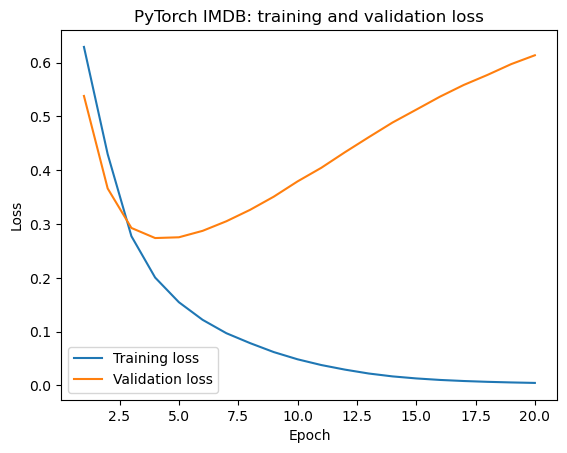

In [45]:
torch_epochs = range(1, len(torch_baseline_history["loss"]) + 1)

plt.figure()
plt.plot(torch_epochs, torch_baseline_history["loss"], label="Training loss")
plt.plot(torch_epochs, torch_baseline_history["val_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("PyTorch IMDB: training and validation loss")
plt.legend()
plt.show()

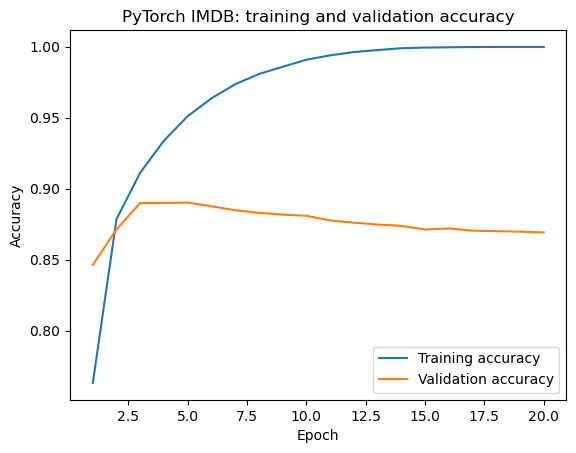

In [46]:
plt.figure()
plt.plot(torch_epochs, torch_baseline_history["accuracy"], label="Training accuracy")
plt.plot(torch_epochs, torch_baseline_history["val_accuracy"], label="Validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("PyTorch IMDB: training and validation accuracy")
plt.legend()
plt.show()

훈련 손실은 계속 감소하지만 검증 손실이 다시 증가하기 시작한다면
Keras에서와 마찬가지로 과대적합이 나타나고 있다고 볼 수 있다.

### PyTorch에서 L2 가중치 규제 적용

PyTorch에서는 optimizer의 `weight_decay`를 이용하여
L2 규제에 해당하는 가중치 감쇠를 적용하는 방법이 널리 사용된다.

여기서는 기본 모델과 같은 구조를 사용하고
`Adam(..., weight_decay=0.002)`를 적용한다.

In [47]:
torch_l2 = ImdbMLP(dropout_rate=0.0).to(device)

loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(
    torch_l2.parameters(),
    weight_decay=0.002
)

torch_l2_history = {
    "loss": [],
    "accuracy": [],
    "val_loss": [],
    "val_accuracy": [],
}

epochs = 20

for epoch in range(epochs):
    train_loss, train_acc = train_one_epoch(
        torch_l2,
        train_loader,
        loss_fn,
        optimizer,
        device,
    )

    val_loss, val_acc = evaluate_binary(
        torch_l2,
        val_loader,
        loss_fn,
        device,
    )

    torch_l2_history["loss"].append(train_loss)
    torch_l2_history["accuracy"].append(train_acc)
    torch_l2_history["val_loss"].append(val_loss)
    torch_l2_history["val_accuracy"].append(val_acc)

    print(
        f"epoch {epoch + 1:2d}: "
        f"loss={train_loss:.4f}, "
        f"accuracy={train_acc:.4f}, "
        f"val_loss={val_loss:.4f}, "
        f"val_accuracy={val_acc:.4f}"
    )

epoch  1: loss=0.6340, accuracy=0.7560, val_loss=0.5488, val_accuracy=0.8459
epoch  2: loss=0.4504, accuracy=0.8759, val_loss=0.3872, val_accuracy=0.8727
epoch  3: loss=0.3091, accuracy=0.9041, val_loss=0.3125, val_accuracy=0.8841
epoch  4: loss=0.2395, accuracy=0.9229, val_loss=0.2875, val_accuracy=0.8876
epoch  5: loss=0.1995, accuracy=0.9354, val_loss=0.2825, val_accuracy=0.8854
epoch  6: loss=0.1722, accuracy=0.9462, val_loss=0.2839, val_accuracy=0.8815
epoch  7: loss=0.1523, accuracy=0.9551, val_loss=0.2919, val_accuracy=0.8796
epoch  8: loss=0.1352, accuracy=0.9614, val_loss=0.2988, val_accuracy=0.8801
epoch  9: loss=0.1215, accuracy=0.9657, val_loss=0.3078, val_accuracy=0.8787
epoch 10: loss=0.1086, accuracy=0.9722, val_loss=0.3200, val_accuracy=0.8782
epoch 11: loss=0.0983, accuracy=0.9746, val_loss=0.3364, val_accuracy=0.8724
epoch 12: loss=0.0928, accuracy=0.9761, val_loss=0.3448, val_accuracy=0.8743
epoch 13: loss=0.0856, accuracy=0.9795, val_loss=0.3584, val_accuracy=0.8729

### PyTorch 기본 모델과 L2 규제 모델 비교

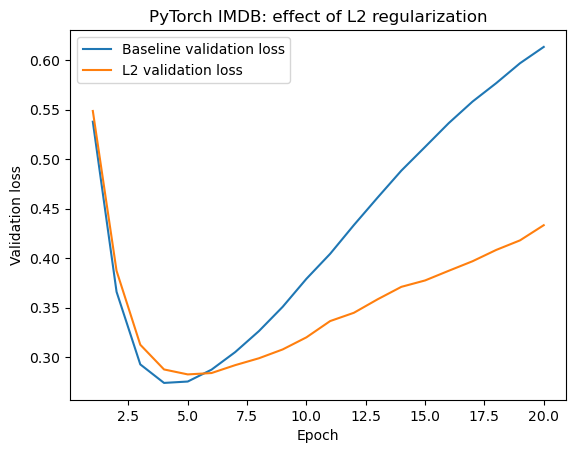

In [48]:
plt.figure()

plt.plot(
    range(1, len(torch_baseline_history["val_loss"]) + 1),
    torch_baseline_history["val_loss"],
    label="Baseline validation loss",
)

plt.plot(
    range(1, len(torch_l2_history["val_loss"]) + 1),
    torch_l2_history["val_loss"],
    label="L2 validation loss",
)

plt.xlabel("Epoch")
plt.ylabel("Validation loss")
plt.title("PyTorch IMDB: effect of L2 regularization")
plt.legend()
plt.show()

### 드롭아웃과 조기 종료 적용

PyTorch에서는 Keras의 `EarlyStopping`과 같은 동작을
훈련 루프에서 직접 구현할 수 있다.

다음 값을 직접 관리한다.

- 현재까지 가장 낮은 검증 손실
- 검증 손실이 개선되지 않은 에포크 수
- 가장 좋은 시점의 모델 파라미터

검증 손실이 `patience`만큼 연속해서 개선되지 않으면 훈련을 종료한다.

In [49]:
import copy

torch_regularized = ImdbMLP(dropout_rate=0.5).to(device)

loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(torch_regularized.parameters())

patience = 2
best_val_loss = float("inf")
best_state = None
epochs_without_improvement = 0

torch_regularized_history = {
    "loss": [],
    "accuracy": [],
    "val_loss": [],
    "val_accuracy": [],
}

max_epochs = 20

for epoch in range(max_epochs):
    train_loss, train_acc = train_one_epoch(
        torch_regularized,
        train_loader,
        loss_fn,
        optimizer,
        device,
    )

    val_loss, val_acc = evaluate_binary(
        torch_regularized,
        val_loader,
        loss_fn,
        device,
    )

    torch_regularized_history["loss"].append(train_loss)
    torch_regularized_history["accuracy"].append(train_acc)
    torch_regularized_history["val_loss"].append(val_loss)
    torch_regularized_history["val_accuracy"].append(val_acc)

    print(
        f"epoch {epoch + 1:2d}: "
        f"loss={train_loss:.4f}, "
        f"accuracy={train_acc:.4f}, "
        f"val_loss={val_loss:.4f}, "
        f"val_accuracy={val_acc:.4f}"
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = copy.deepcopy(torch_regularized.state_dict())
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= patience:
        print(f"Early stopping at epoch {epoch + 1}")
        break

# 검증 손실이 가장 낮았던 시점의 파라미터 복원
if best_state is not None:
    torch_regularized.load_state_dict(best_state)

epoch  1: loss=0.6639, accuracy=0.6257, val_loss=0.6010, val_accuracy=0.8357
epoch  2: loss=0.5618, accuracy=0.7767, val_loss=0.4640, val_accuracy=0.8671
epoch  3: loss=0.4388, accuracy=0.8443, val_loss=0.3514, val_accuracy=0.8802
epoch  4: loss=0.3437, accuracy=0.8849, val_loss=0.2962, val_accuracy=0.8894
epoch  5: loss=0.2834, accuracy=0.9065, val_loss=0.2806, val_accuracy=0.8911
epoch  6: loss=0.2405, accuracy=0.9255, val_loss=0.2716, val_accuracy=0.8909
epoch  7: loss=0.2030, accuracy=0.9339, val_loss=0.2753, val_accuracy=0.8913
epoch  8: loss=0.1798, accuracy=0.9463, val_loss=0.2800, val_accuracy=0.8924
Early stopping at epoch 8


### 기본 모델, L2 규제 모델, 드롭아웃 모델 비교

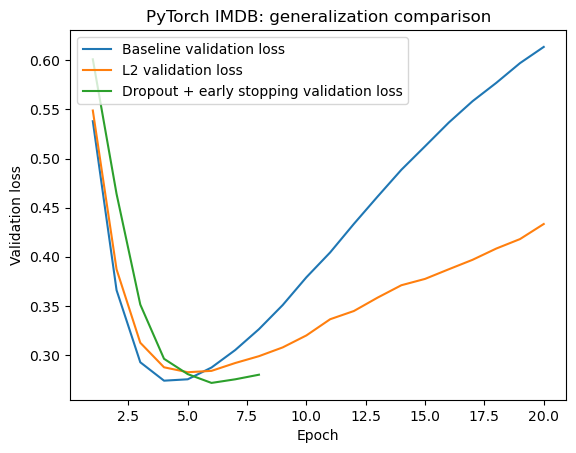

In [50]:
plt.figure()

plt.plot(
    range(1, len(torch_baseline_history["val_loss"]) + 1),
    torch_baseline_history["val_loss"],
    label="Baseline validation loss",
)

plt.plot(
    range(1, len(torch_l2_history["val_loss"]) + 1),
    torch_l2_history["val_loss"],
    label="L2 validation loss",
)

plt.plot(
    range(1, len(torch_regularized_history["val_loss"]) + 1),
    torch_regularized_history["val_loss"],
    label="Dropout + early stopping validation loss",
)

plt.xlabel("Epoch")
plt.ylabel("Validation loss")
plt.title("PyTorch IMDB: generalization comparison")
plt.legend()
plt.show()

### 테스트 데이터에서 최종 평가

In [51]:
torch_baseline_test_loss, torch_baseline_test_acc = evaluate_binary(
    torch_baseline,
    test_loader,
    loss_fn,
    device,
)

torch_l2_test_loss, torch_l2_test_acc = evaluate_binary(
    torch_l2,
    test_loader,
    loss_fn,
    device,
)

torch_regularized_test_loss, torch_regularized_test_acc = evaluate_binary(
    torch_regularized,
    test_loader,
    loss_fn,
    device,
)

print("baseline test loss:", torch_baseline_test_loss)
print("baseline test accuracy:", torch_baseline_test_acc)
print()
print("L2 test loss:", torch_l2_test_loss)
print("L2 test accuracy:", torch_l2_test_acc)
print()
print("dropout + early stopping test loss:", torch_regularized_test_loss)
print("dropout + early stopping test accuracy:", torch_regularized_test_acc)

baseline test loss: 0.6651529648971558
baseline test accuracy: 0.86012

L2 test loss: 0.4571903980636597
L2 test accuracy: 0.85564

dropout + early stopping test loss: 0.28553674562454223
dropout + early stopping test accuracy: 0.8846


Keras와 PyTorch에서 수행한 핵심 과정은 같다.

| 과정 | Keras | PyTorch |
|---|---|---|
| L2 가중치 규제 | `kernel_regularizer=regularizers.l2(...)` | optimizer의 `weight_decay` |
| 드롭아웃 | `layers.Dropout()` | `nn.Dropout()` |
| 검증 | `validation_data` | 별도의 검증 루프 |
| 조기 종료 | `EarlyStopping` callback | 검증 손실을 직접 비교하여 구현 |
| 최적 파라미터 복원 | `restore_best_weights=True` | `state_dict()`를 저장하고 다시 불러옴 |
| 훈련 기록 | `History` 객체 | 리스트 또는 딕셔너리에 직접 저장 |

> **두 프레임워크가 구현하는 일반화의 원리는 같지만, PyTorch에서는 훈련과 검증 과정을 코드에서 더 명시적으로 관리한다.**

테스트 정확도만 비교하지 말고 **검증 손실 곡선의 형태**도 함께 확인한다.

생각해볼 점:

- L2 가중치 규제를 적용했을 때 과대적합이 시작되는 시점이나 정도가 달라졌는가?
- 드롭아웃을 적용했을 때 검증 손실의 증가가 완만해졌는가?
- L2와 드롭아웃은 같은 방식으로 모델의 복잡도를 제한하는가?
- 조기 종료는 몇 번째 에포크에서 훈련을 멈추었는가?
- 규제가 항상 테스트 정확도를 높이는가?

## PyTorch에서는 어떻게 연결될까?

P1에서 PyTorch의 훈련 루프를 직접 구현했다.

P2에서 중요한 것은 훈련 루프 자체를 다시 작성하는 것이 아니라
**문제 유형에 따라 출력층과 손실함수가 어떻게 연결되는지** 이해하는 것이다.

Keras와 PyTorch에서는 다음과 같이 대응한다.

| 문제 | Keras 출력층 | Keras loss | PyTorch 출력층 | PyTorch loss |
|---|---|---|---|---|
| 이진 분류 | `Dense(1, sigmoid)` | `binary_crossentropy` | `Linear(..., 1)` | `BCEWithLogitsLoss()` |
| 다중 클래스 분류 | `Dense(K, softmax)` | `sparse_categorical_crossentropy` | `Linear(..., K)` | `CrossEntropyLoss()` |
| 회귀 | `Dense(1)` | `mse` | `Linear(..., 1)` | `MSELoss()` |

PyTorch의 `BCEWithLogitsLoss()`와 `CrossEntropyLoss()`는
각각 sigmoid 또는 softmax에 해당하는 계산을 손실 계산과 결합하여 처리하므로
모델의 마지막 층에 해당 활성화 함수를 별도로 넣지 않는 것이 일반적이다.

In [52]:
import torch
from torch import nn

# 이진 분류
binary_torch_output = nn.Linear(16, 1)
binary_torch_loss = nn.BCEWithLogitsLoss()

# 다중 클래스 분류
multiclass_torch_output = nn.Linear(64, 46)
multiclass_torch_loss = nn.CrossEntropyLoss()

# 회귀
regression_torch_output = nn.Linear(64, 1)
regression_torch_loss = nn.MSELoss()

print(binary_torch_output)
print(multiclass_torch_output)
print(regression_torch_output)

Linear(in_features=16, out_features=1, bias=True)
Linear(in_features=64, out_features=46, bias=True)
Linear(in_features=64, out_features=1, bias=True)


## 세 문제 비교

이번 실습에서 가장 중요한 차이는 **신경망의 앞부분보다 출력층과 손실함수**에 있다.

| 문제 | 최종 출력의 의미 | 출력층 | 손실함수 |
|---|---|---|---|
| IMDB | 긍정일 가능성 | 1 + sigmoid | binary crossentropy |
| Reuters | 46개 주제의 확률 | 46 + softmax | sparse categorical crossentropy |
| California Housing | 주택가격 | 1 + 활성화 없음 | MSE |

> **문제의 타깃이 무엇인지 먼저 파악한 뒤 출력층, 손실함수, 평가지표를 결정한다.**

## 실습 정리

이번 실습의 전체 흐름은 다음과 같다.

> **문제 유형 확인 → 데이터 준비 → 출력층과 손실함수 선택 → 훈련 → 검증 → 테스트 평가 → 일반화 개선**

다음을 기억한다.

- 이진 분류에서는 하나의 sigmoid 출력을 사용할 수 있다.
- 다중 클래스 분류에서는 클래스 수만큼의 softmax 출력을 사용할 수 있다.
- 회귀에서는 출력값의 범위를 제한하지 않는 출력층을 사용할 수 있다.
- 검증 데이터는 모델 선택과 훈련 과정 판단에 사용하고, 테스트셋은 최종 평가에 사용한다.
- California Housing 회귀에서는 3겹 교차 검증을 이용하여 RMSE의 평균으로 일반화 성능을 평가한다.
- 훈련 성능이 계속 좋아져도 검증 성능은 나빠질 수 있다.
- 드롭아웃과 조기 종료는 과대적합을 완화하고 일반화 성능을 개선하는 데 사용할 수 있다.
- `ModelCheckpoint`를 이용하면 검증 성능이 가장 좋았던 모델을 저장할 수 있다.
- `ReduceLROnPlateau`를 이용하면 검증 성능이 정체될 때 학습률을 줄일 수 있다.
- PyTorch에서는 문제 유형에 맞는 손실함수를 선택하되, 일부 활성화 계산이 손실함수에 포함된다.
- 과대적합을 완화하기 위해 L2 가중치 규제, 드롭아웃, 조기 종료를 적용하고 검증 손실의 변화를 비교한다.

## 확인 과제

1. IMDB 모델의 출력층을 `Dense(2, activation="softmax")`로 바꾸려면 타깃과 손실함수를 어떻게 바꾸어야 하는지 설명하라.
2. Reuters에서 `accuracy`와 `top-3 accuracy`가 서로 다른 정보를 제공하는 이유를 설명하라.
3. California Housing 회귀 모델의 마지막 층에 sigmoid를 사용하면 어떤 문제가 생길 수 있는지 설명하라.
4. IMDB 기본 모델과 규제 모델의 검증 손실 곡선을 비교하고, 과대적합이 시작되는 시점을 설명하라.
5. 테스트셋을 여러 모델을 선택하는 과정에서 반복해서 사용하면 안 되는 이유를 설명하라.
6. California Housing에서 하나의 검증셋 대신 3겹 교차 검증을 사용하는 이유와 세 fold의 RMSE를 평균하는 이유를 설명하라.
7. L2 가중치 규제가 과대적합을 완화하는 원리를 설명하고, 드롭아웃과의 차이를 설명하라.